# **TikTok Data Analysis**

Personal project of: Ramos, Ronn Patrick B.

# **1. Problem Statement**
- What makes a TikTok video go viral?
- Are verified users more successful?

## **Dataset Description**

| Column | Type | Description |
|--------|------|-------------|
| # | int | TikTok assigned number for video with claim/opinion |
| claim_status | object | Opinion or claim status |
| video_id | int | Unique video ID |
| video_duration_sec | int | Duration in seconds |
| video_transcription_text | object | Transcribed text |
| verified_status | object | Verified or not verified |
| author_ban_status | object | Active / under scrutiny / banned |
| video_view_count | float | Total views |
| video_like_count | float | Total likes |
| video_share_count | float | Total shares |
| video_download_count | float | Total downloads |
| video_comment_count | float | Total comments |

# **2. Imports and uploading dataset**


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("tiktok_dataset.csv")
print(df.head())

   # claim_status    video_id  video_duration_sec  \
0  1        claim  7017666017                  59   
1  2        claim  4014381136                  32   
2  3        claim  9859838091                  31   
3  4        claim  1866847991                  25   
4  5        claim  7105231098                  19   

                            video_transcription_text verified_status  \
0  someone shared with me that drone deliveries a...    not verified   
1  someone shared with me that there are more mic...    not verified   
2  someone shared with me that american industria...    not verified   
3  someone shared with me that the metro of st. p...    not verified   
4  someone shared with me that the number of busi...    not verified   

  author_ban_status  video_view_count  video_like_count  video_share_count  \
0      under review          343296.0           19425.0              241.0   
1            active          140877.0           77355.0            19034.0   
2            a

# **3. Data Cleaning**


## Check for missing data

In [17]:
for i in df.columns:
    null_rate = df[i].isna().sum() / len(df) * 100 
    if null_rate > 0 :
        print("{} null rate: {}%".format(i,round(null_rate,2)))

claim_status null rate: 1.54%
video_transcription_text null rate: 1.54%
video_view_count null rate: 1.54%
video_like_count null rate: 1.54%
video_share_count null rate: 1.54%
video_download_count null rate: 1.54%
video_comment_count null rate: 1.54%


## Check for duplicates

In [18]:
df.duplicated().sum()

0

## Check the data types of the columns

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


## Clean the data

In [20]:
# Drop unnecessary column
df = df.drop(columns=["#"])

# Convert categorical columns to category data type
cat_cols = ["claim_status", "verified_status", "author_ban_status"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Clean text column
df["video_transcription_text"] = df["video_transcription_text"].astype("string").str.strip()

# Handle missing values in numerical columns
num_cols = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_download_count",
    "video_comment_count"
]
df[num_cols] = df[num_cols].astype("Int64")  # keeps NaN

# Handle missing values in categorical columns
df["claim_status"] = df["claim_status"].cat.add_categories("unknown").fillna("unknown")

In [21]:
# Final check of data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   claim_status              19382 non-null  category
 1   video_id                  19382 non-null  int64   
 2   video_duration_sec        19382 non-null  int64   
 3   video_transcription_text  19084 non-null  string  
 4   verified_status           19382 non-null  category
 5   author_ban_status         19382 non-null  category
 6   video_view_count          19084 non-null  Int64   
 7   video_like_count          19084 non-null  Int64   
 8   video_share_count         19084 non-null  Int64   
 9   video_download_count      19084 non-null  Int64   
 10  video_comment_count       19084 non-null  Int64   
dtypes: Int64(5), category(3), int64(2), string(1)
memory usage: 1.3 MB


# **4. EDA**

## Univariate Analysis

### Distribution of engagement metrics: 
- views
- likes
- shares

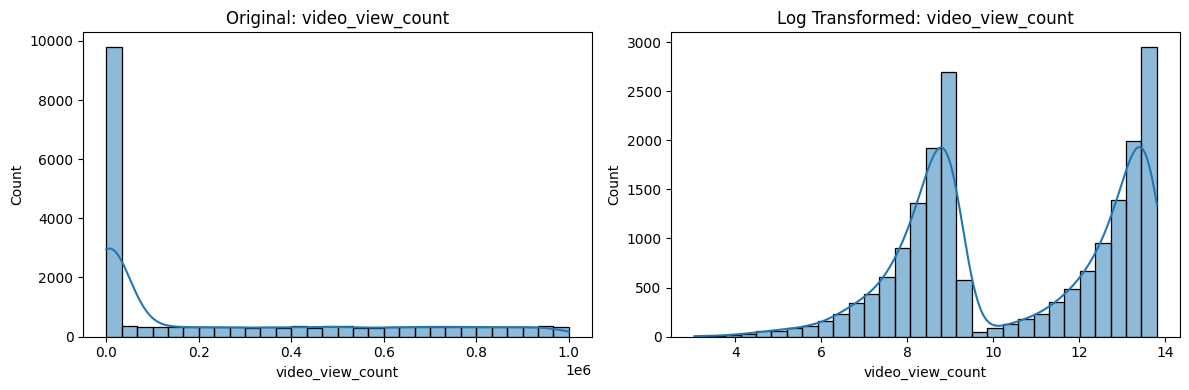

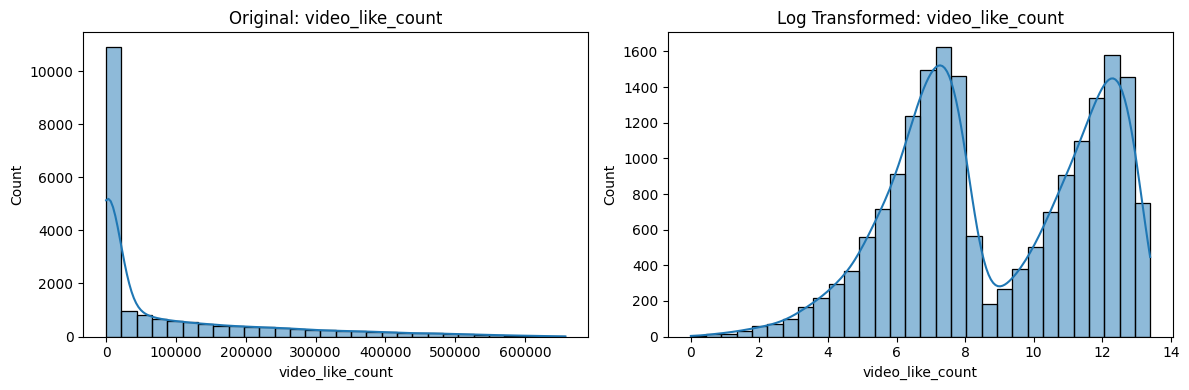

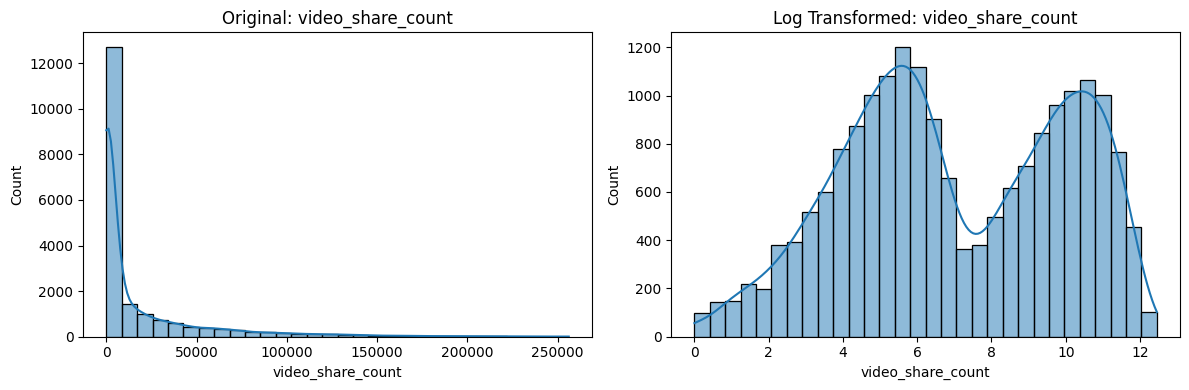

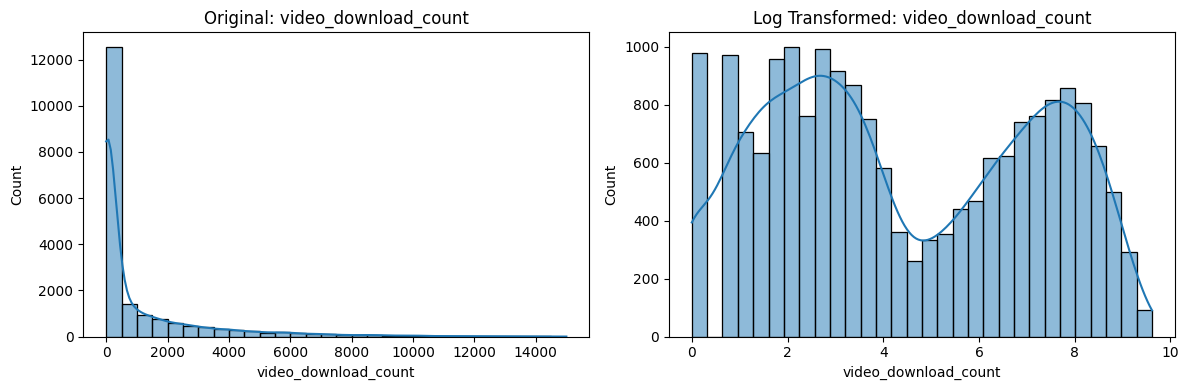

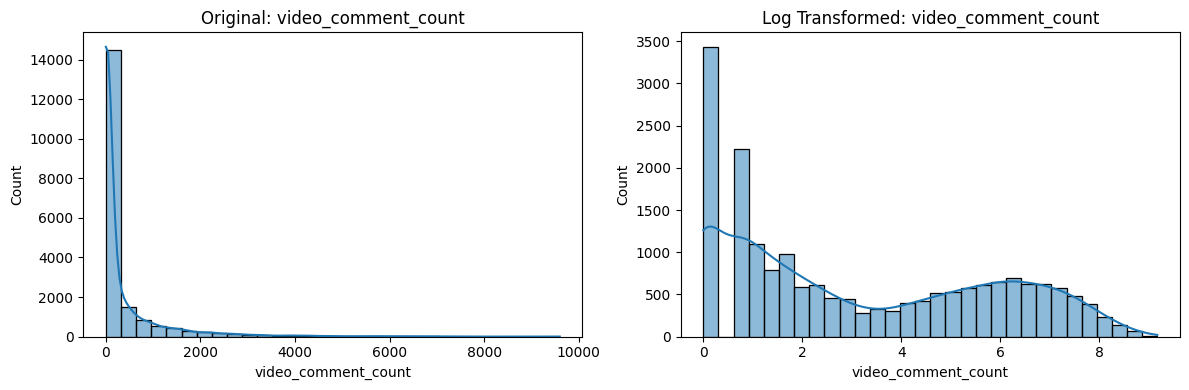

In [22]:
cols = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_download_count",
    "video_comment_count"
    ]

for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # original distribution
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"Original: {col}")

    # log transformed 
    sns.histplot(np.log1p(df[col]), bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"Log Transformed: {col}")

    plt.tight_layout()
    plt.show()

*The original data is heavily skewed, with most videos having low engagement. After applying a log transformation, the distribution becomes clearer and easier to interpret. It also shows two peaks, suggesting that videos fall into two groups: low-engagement and high-engagement (viral) content.*

### Count plots of: 
- verified vs not
- banned, under review or active 
- claim vs opinion

In [23]:
selected_cols = [
    "verified_status",
    "author_ban_status",
    "claim_status"
]

for col in selected_cols:
    print("\n", "="*40)
    print(f" COLUMN: {col}")
    print("="*40)

    counts = df[col].value_counts(dropna=False)
    percent = df[col].value_counts(dropna=False, normalize=True) * 100

    result = pd.DataFrame({
        "count": counts,
        "percentage": percent.round(2).astype(str) + "%"
    })

    print(result)


 COLUMN: verified_status
                 count percentage
verified_status                  
not verified     18142      93.6%
verified          1240       6.4%

 COLUMN: author_ban_status
                   count percentage
author_ban_status                  
active             15663     80.81%
under review        2080     10.73%
banned              1639      8.46%

 COLUMN: claim_status
              count percentage
claim_status                  
claim          9608     49.57%
opinion        9476     48.89%
unknown         298      1.54%


- Most videos *(93.6%)* are from non-verified users. 
- Only a small fraction of users *(8.46%)* are banned, while a slightly larger group *(10.73%)* are under review.
- Claims and opinions are nearly evenly distributed *(49.57% vs 48.89%)*. **

## Bivariate Analysis

### We create a new variable: engagement_rate

In [24]:
df["engagement_rate"] = (
    df["video_like_count"] +
    df["video_comment_count"] +
    df["video_share_count"] +
    df["video_download_count"]
) / df["video_view_count"].replace(0, 1) # avoid division by zero

*We created an engagement rate to measure user interaction relative to views, calculated as total engagements (likes, comments, shares, and downloads) divided by views.*

$$
\text{Engagement Rate} =
\frac{\text{Likes} + \text{Comments} + \text{Shares} + \text{Downloads}}{\text{Views}}
$$


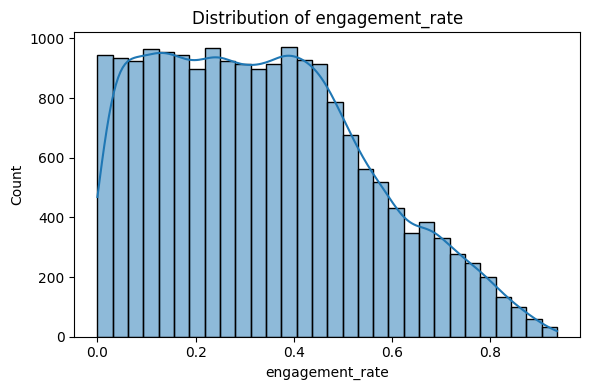

In [25]:
plt.figure(figsize=(6,4))

sns.histplot(df["engagement_rate"], bins=30, kde=True)
plt.title("Distribution of engagement_rate")

plt.tight_layout()
plt.show()

### verified_status vs engagement_rate

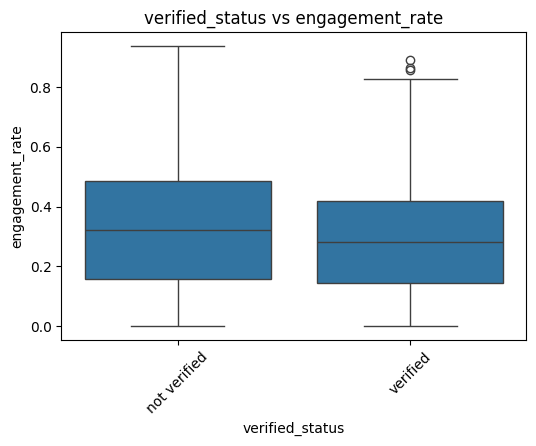

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="verified_status", y="engagement_rate")
plt.title("verified_status vs engagement_rate")
plt.xticks(rotation=45)
plt.show()

*Non-verified users show slightly higher engagement on average, though the difference is small. They also reach higher peaks, but this may be influenced by their large representation in the dataset (93.6%), which increases the chance of extreme values.*

### author_ban_status vs engagement

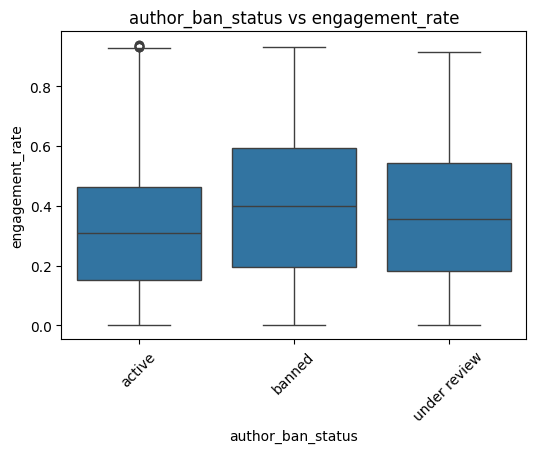

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="author_ban_status", y="engagement_rate")
plt.title("author_ban_status vs engagement_rate")
plt.xticks(rotation=45)
plt.show()

*Banned authors show slightly higher engagement compared to active and under-review users, though the difference is not very large. They also tend to reach higher peaks in engagement, but there is considerable variability across all groups, suggesting that engagement alone does not determine an author’s status.*

### claim_status vs engagement

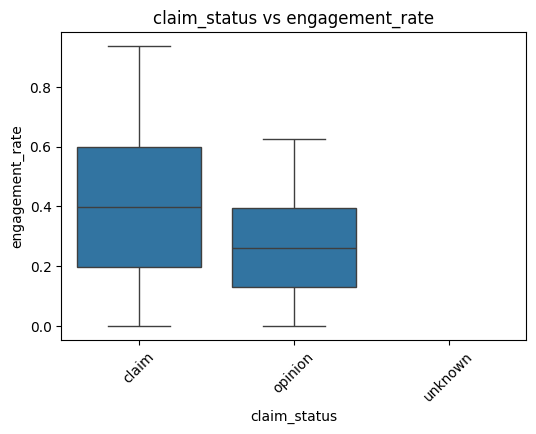

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="claim_status", y="engagement_rate")
plt.title("claim_status vs engagement_rate")
plt.xticks(rotation=45)
plt.show()

In [29]:
# Calculate mean engagement per claim_status
means = (
    df.groupby('claim_status', observed=True)['engagement_rate']
      .mean()
)

# Safely extract values
claim_mean = means.get('claim', 0)
opinion_mean = means.get('opinion', 0)

# Avoid division by zero
if opinion_mean != 0:
    lift = ((claim_mean - opinion_mean) / opinion_mean) * 100
    print(f"Claim content has {lift:.1f}% higher engagement than opinion content.")
else:
    print("Cannot compute lift because opinion engagement is zero.")

Claim content has 51.1% higher engagement than opinion content.


*Videos labeled as claims tend to have higher engagement rates on average and reach higher peak values compared to opinions, suggesting that content presented as “facts” attracts more attention, but performance isn’t guaranteed.*

### video_duration_sec vs engagement_rate

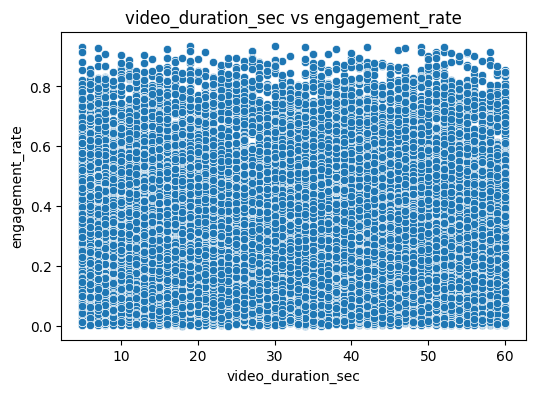

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="video_duration_sec", y="engagement_rate")
plt.title("video_duration_sec vs engagement_rate")
plt.show()

*The points are widely scattered across the plot, indicating no clear relationship between video duration and engagement rate.*

# **5. Insights & Recommendations**


## Insights
- Most videos (93.6%) are from non-verified users, indicating that the platform is dominated by non-verified creators.
- The dataset is nearly evenly split between claims and opinions, allowing for balanced comparison between the two content types.
- Engagement metrics are highly skewed, with a small number of videos receiving significantly higher engagement, indicating the presence of viral content.
- Claim-based videos tend to have higher average and peak engagement compared to opinion-based videos.
- Non-verified users show slightly higher average engagement rates and higher peaks, though this may be influenced by their large representation in the dataset.
- There is no clear relationship between video duration and engagement rate, suggesting that video length does not strongly impact user interaction.

## Recommendations
- Focus on identifying characteristics of high-performing (viral) videos, as they drive a large portion of engagement.
- Further analyze claim-based content to understand why it generates higher engagement and whether it should be prioritized or moderated.
- Consider segmenting users (e.g., verified vs non-verified) in future analysis to better understand engagement patterns.
- Since video duration shows little impact on engagement, prioritize content quality and relevance over length.
- Use engagement rate as a key metric instead of raw views to better evaluate content performance.

# **6. Conclusion: Answers to Problem Statement**

## 1. What makes a TikTok video go viral?
*Videos go viral mainly because of their content and how people interact with them*

- Videos with claim-based content tend to achieve higher average and peak engagement compared to opinion-based videos.
- Engagement is highly uneven, with just a few videos getting most of the likes, comments, and shares (these are the viral ones).
- Video duration shows little to no clear relationship with engagement, suggesting that length is not a key driver of performance.

## 2. Are verified users more successful?
*Whether a user is verified does not strongly affect engagement. Non-verified users can perform just as well or even better.*

- Non-verified users show slightly higher average engagement rates and higher peak values.
- However, this may be influenced by their large representation in the dataset (93.6%).
- Verified users still produce some high-performing outliers, indicating they can achieve strong engagement, but not consistently outperform others.

---
Overall, engagement appears to be influenced more by content characteristics and audience behavior than by user verification status or video duration.